In [15]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import numpy as np
from datetime import datetime
import pandas as pd

In [16]:
slc_path = "Biomass_data/Test_Scene/20260216.hh.slc"
slc_par_path = "Biomass_data/Test_Scene/20260216.hh.slc.par"
annot_path = "Biomass_data/BIO_S1_SCS__1S_20260216T155114_20260216T155133_T_G01_M02_C03_T010_F182_01_DMY9IM/annotation/bio_s1_scs__1s_20260216t155114_20260216t155133_t_g01_m02_c03_t010_f182_annot.xml"

In [17]:
def parse_slc_par(par_file):
    params = {}
    with open(par_file, 'r') as f:
        for line in f:
            if ':' in line:
                key, _, val = line.partition(':')
                params[key.strip()] = val.strip().split()
    return params

par = parse_slc_par(slc_par_path)

range_samples = int(par['range_samples'][0])
azimuth_lines = int(par['azimuth_lines'][0])


In [18]:
def read_slc(slc_file, range_samples, azimuth_lines):
    dt = np.dtype('>f4')  # big-endian 32-bit float
    raw = np.fromfile(slc_file, dtype=dt)
    # interleaved real/imag → complex
    complex_data = raw[0::2] + 1j * raw[1::2]
    return complex_data.reshape(azimuth_lines, range_samples)

slc = read_slc(slc_path, range_samples, azimuth_lines)

In [19]:
xml_path = annot_path

tree = ET.parse(xml_path)
root = tree.getroot()

def findtext(path: str):
    t = root.findtext(path)
    return t.strip() if t else None

# ---- Global parameters ----
carrier_hz = float(findtext(".//radarCarrierFrequency"))
heading_deg = float(findtext(".//platformHeading"))
range_ps_m = float(findtext(".//rangePixelSpacing"))
az_ps_m = float(findtext(".//azimuthPixelSpacing"))
t_first = float(findtext(".//firstSampleSlantRangeTime"))
t_last  = float(findtext(".//lastSampleSlantRangeTime"))

# PRF is stored as prfList/prf/value
prf_node = root.find(".//prfList/prf/value")
prf_hz = float(prf_node.text.strip()) if prf_node is not None else None

print("carrier_hz:", carrier_hz)
print("prf_hz:", prf_hz)
print("platformHeading_deg:", heading_deg)
print("rangePixelSpacing_m:", range_ps_m)
print("azimuthPixelSpacing_m:", az_ps_m)
print("slantRangeTime_first_last_s:", t_first, t_last)

# ---- Doppler estimate list ----
rows = []
for dc in root.findall(".//dopplerParameters/dcEstimateList/dcEstimate"):
    rows.append({
        "azimuthTime": (dc.findtext("azimuthTime") or "").strip(),
        "t0": float((dc.findtext("t0") or "nan").strip()),
        "geometryDCPolynomial": (dc.findtext("geometryDCPolynomial") or "").strip(),
        "combinedDCPolynomial": (dc.findtext("combinedDCPolynomial") or "").strip(),
        "combinedDCRMSError": float((dc.findtext("combinedDCRMSError") or "nan").strip()),
        "combinedDCRMSErrorAboveThreshold": (dc.findtext("combinedDCRMSErrorAboveThreshold") or "").strip(),
    })

df = pd.DataFrame(rows)
print("\nDoppler estimates:", df.shape)
print(df.head(3))

carrier_hz: 435000000.0
prf_hz: 1576.34968328055
platformHeading_deg: -166.24001416195455
rangePixelSpacing_m: 19.813869327800077
azimuthPixelSpacing_m: 6.7088732645224045
slantRangeTime_first_last_s: 0.004863753941649388 0.005041937849490555

Doppler estimates: (25, 6)
                  azimuthTime        t0  \
0  2026-02-16T15:51:11.808667  0.004861   
1  2026-02-16T15:51:12.808667  0.004861   
2  2026-02-16T15:51:13.808667  0.004861   

                                geometryDCPolynomial combinedDCPolynomial  \
0  1.03808101168443 520.940269682678 -606414.8918...                        
1  1.20315650212802 606.205006657984 -705651.9454...                        
2  1.15681441850823 572.924724835615 -670324.6989...                        

   combinedDCRMSError combinedDCRMSErrorAboveThreshold  
0                 0.0                            false  
1                 0.0                            false  
2                 0.0                            false  


In [20]:
def parse_poly(poly_str: str):
    if not poly_str:
        return None
    return [float(x) for x in poly_str.split()]

df["geom_poly_coeffs"] = df["geometryDCPolynomial"].apply(parse_poly)
print(df["geom_poly_coeffs"].head())

0    [1.03808101168443, 520.940269682678, -606414.8...
1    [1.20315650212802, 606.205006657984, -705651.9...
2    [1.15681441850823, 572.924724835615, -670324.6...
3    [0.955462178790921, 496.422213139496, -575550....
4    [1.05136439570117, 545.570228843327, -632991.7...
Name: geom_poly_coeffs, dtype: object


In [21]:
prf = prf_hz
x = slc - np.mean(slc, axis=0, keepdims=True)

In [22]:
S = np.fft.fftshift(np.fft.fft(x, axis=0), axes=0)
P = np.abs(S)**2
freqs = np.fft.fftshift(np.fft.fftfreq(x.shape[0], d=1/prf))
p_sum = np.sum(P, axis=1)
dc_hz = float(np.sum(freqs * p_sum) / np.sum(p_sum))

In [23]:
def dc_map_overlap(
    slc: np.ndarray,
    prf: float,
    win_az: int = 512,
    win_rg: int = 256,
    stride_az: int = 256,
    stride_rg: int = 64,
):
    """
    Doppler centroid (Hz) from overlapping windows.
    slc: complex array [azimuth_lines, range_samples]
    Returns:
      dc_hz: 2D array [n_az_windows, n_rg_windows]
    """
    L, W = slc.shape

    # window start indices
    az_starts = np.arange(0, L - win_az + 1, stride_az)
    rg_starts = np.arange(0, W - win_rg + 1, stride_rg)

    # Doppler frequency axis (Hz) for azimuth FFT length win_az
    freqs = np.fft.fftshift(np.fft.fftfreq(win_az, d=1 / prf))

    dc = np.full((az_starts.size, rg_starts.size), np.nan, dtype=np.float64)

    for ia, a0 in enumerate(az_starts):
        a1 = a0 + win_az
        for ir, r0 in enumerate(rg_starts):
            r1 = r0 + win_rg
            w = slc[a0:a1, r0:r1]

            # reduce leakage: remove mean per range-bin inside window
            w = w - np.mean(w, axis=0, keepdims=True)

            # azimuth spectrum
            S = np.fft.fftshift(np.fft.fft(w, axis=0), axes=0)
            P = np.abs(S) ** 2

            p_sum = np.sum(P, axis=1)  # sum over range bins
            denom = np.sum(p_sum)
            if denom > 0:
                dc[ia, ir] = float(np.sum(freqs * p_sum) / denom)

    return dc, az_starts, rg_starts

In [24]:
dc_hz, az_starts, rg_starts = dc_map_overlap(slc, prf)
print(dc_hz.shape)
print("Hz stats:", np.nanmin(dc_hz), np.nanmedian(dc_hz), np.nanmax(dc_hz))

(76, 18)
Hz stats: -19.55232768474763 2.0702381703557045 23.31932024202949


In [25]:
annot = annot_path
root = ET.parse(annot).getroot()

def get_float(tag_path):
    t = root.findtext(tag_path)
    if t is None:
        return None
    return float(t.strip())

t_first = get_float(".//firstSampleSlantRangeTime")
dt_sr  = get_float(".//rangeTimeInterval")  # may be named differently in some files

print("t_first:", t_first, "dt_sr:", dt_sr)

# --- read dcEstimateList (we'll use the first entry for now, step-by-step) ---
dc_est = root.find(".//dopplerParameters/dcEstimateList/dcEstimate")
assert dc_est is not None, "No dcEstimate found"

t0 = float(dc_est.findtext("t0").strip())
poly_str = (dc_est.findtext("geometryDCPolynomial") or "").strip()
assert poly_str, "geometryDCPolynomial empty in first dcEstimate"

coeff = np.array([float(x) for x in poly_str.split()], dtype=np.float64)

print("t0:", t0)
print("coeff:", coeff)

def eval_poly(t, t0, coeff):
    x = t - t0
    # coeff[0] + coeff[1]*x + coeff[2]*x^2 ...
    # use Horner for stability
    y = 0.0
    for c in coeff[::-1]:
        y = y * x + c
    return y

# --- Build predicted DC for each range-window center ---
win_rg = 64
rg_centers = rg_starts + (win_rg // 2)   # sample indices at window center
t_centers = t_first + rg_centers * dt_sr # slant-range time at those centers (seconds)

dc_pred_1d = np.array([eval_poly(t, t0, coeff) for t in t_centers], dtype=np.float64)  # Hz, length 45

# Expand to 2D by repeating along azimuth windows
dc_pred = np.repeat(dc_pred_1d[None, :], dc_hz.shape[0], axis=0)

# DCA (measured - predicted)
dca = dc_hz - dc_pred

print("DCA stats:", np.nanmin(dca), np.nanmedian(dca), np.nanmax(dca))

t_first: 0.004863753941649388 dt_sr: 1.32183907894041e-07
t0: 0.00486071371720851
coeff: [ 1.03808101e+00  5.20940270e+02 -6.06414892e+05  8.16469796e+08
 -7.99427051e+11]
DCA stats: -20.59416424898287 0.9912823950469117 22.21397567898882


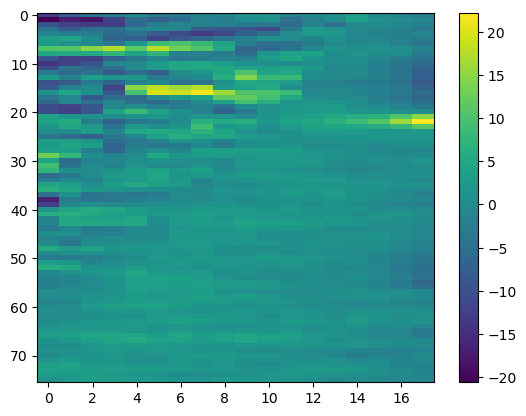

In [26]:
plt.imshow(dca, aspect='auto')
plt.colorbar()

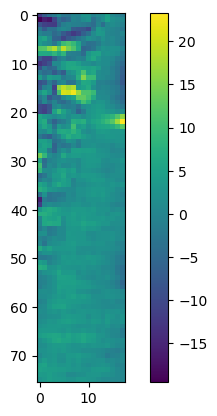

In [27]:
plt.imshow(dc_hz)
plt.colorbar()